In [117]:
import numpy as np
import os
import h5py
import math
import matplotlib.pyplot as plt
import cv2
# import tensorflow as tf
# from tensorflow.keras.applications import ResNet50
# from tensorflow.keras.applications.resnet50 import preprocess_input
from skimage.metrics import structural_similarity as ssim

In [118]:
def interval(n_frame, frame2use):
    incr = n_frame / frame2use
    incr = math.floor(incr)
    idx = []
    for i in range(0, n_frame, int(incr)):
        idx.append(i)
    
    return idx[0:frame2use]

def frame_count(video_path, manual=True):
    def manual_count(handler):
        frames = 0
        while True:
            status, frame = handler.read()
            if not status:
                break
            frames += 1
        return frames 

    cap = cv2.VideoCapture(video_path)
    # Slow, inefficient but 100% accurate method 
    if manual:
        frames = manual_count(cap)
    # Fast, efficient but inaccurate method
    else:
        try:
            frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        except:
            frames = manual_count(cap)
    cap.release()
    return frames

def load_video(path, max_frames):
    n_frame = frame_count(path)
    print(n_frame)
    if n_frame <= max_frames:
        idx = [i for i in range(n_frame)]
    else:
        idx = interval(n_frame, max_frames)
    cap = cv2.VideoCapture(path)
    frames = []
    try:
        i = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if i in idx:
                
                
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                frame = cv2.resize(frame, (96, 96))
                w, h = frame.shape
                frame = np.reshape(frame, (w, h, 1))

                frame = frame / 255
                frames.append(frame)

                if len(frames) == max_frames:
                    break
            else:
                pass
            i = i +1

    finally:
        cap.release()
    while(len(frames) < max_frames):
        frames.insert(0, np.zeros(shape = (w, h, 1)))
        #frames.append(np.zeros(shape = (w, h, 1)))
    frames = np.array(frames)
    return frames

def euclidean(A, B):
    return np.linalg.norm(A.flatten() - B.flatten())

def sampling(x, t):
    sampled = np.zeros((96, 96, 1))
    sampled_data = []
    for i in range(len(x)):
        if i == 0:
            sampled = x[i]
            sampled_data.append(sampled)
        else:
            # similarity = euclidean(sampled, x[i])
            # similarity = gaussian_kernel(sampled, x[i], 1)
            w, h, _ = sampled.shape
                            
            sampled_img = np.reshape(sampled, (w, h))
            new = x[i]
            new = np.reshape(new, (w, h))
            similarity  = ssim(sampled_img, new, data_range=new.max() - new.min())
            
            print(similarity)
            if similarity <= t:
                sampled = x[i]
                sampled_data.append(sampled)
            else:
                pass
    return np.array(sampled_data)

def load_video_new(path):
    cap = cv2.VideoCapture(path)
    vid = []
    while(cap.isOpened()):
        ret, frame = cap.read()

        
        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame = cv2.resize(frame, (96, 96))
        w, h = frame.shape
        frame = np.reshape(frame, (w, h, 1))

        frame = frame / 255
        vid.append(frame)


    vid = np.array(vid)
    cap.release()
    cv2.destroyAllWindows()
    return vid

def load_video_lifes(path, max_frames):
    cap = cv2.VideoCapture(path)
    frames = []
    try:
       
        while True:
            ret, frame = cap.read()
            if not ret:
                break
  
                
                
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            frame = cv2.resize(frame, (96, 96))
            w, h = frame.shape
            frame = np.reshape(frame, (w, h, 1))

            frame = frame / 255
            frames.append(frame)

            if len(frames) == max_frames:
                break



    finally:
        cap.release()
    while(len(frames) < max_frames):
        frames.insert(0, np.zeros(shape = (w, h, 1)))
        #frames.append(np.zeros(shape = (w, h, 1)))
    frames = np.array(frames)
    return frames

def load_video_10mid(path):
    cap = cv2.VideoCapture(path)
    frames = []
    try:
       
        while True:
            ret, frame = cap.read()
            if not ret:
                break
  
                
                
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            frame = cv2.resize(frame, (96, 96))
            w, h = frame.shape
            frame = np.reshape(frame, (w, h, 1))

            frame = frame / 255
            frames.append(frame)




    finally:
        cap.release()
    # while(len(frames) < max_frames):
    #     frames.insert(0, np.zeros(shape = (w, h, 1)))
        #frames.append(np.zeros(shape = (w, h, 1)))
    frames = np.array(frames)

    n = len(frames)
    middle_start = (n // 2) - 5 # Start 5 elements before the middle
    middle_end = (n // 2) + 5   # End 5 elements after the middle

    # Ensure indices are within array bounds
    middle_start = max(0, middle_start)
    middle_end = min(n, middle_end)
    return frames[middle_start:middle_end]


def load_video_new_sota(path):
    cap = cv2.VideoCapture(path)
    frames = []
    try:
       
        while True:
            ret, frame = cap.read()
            if not ret:
                break
  
                
                
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            frame = cv2.resize(frame, (96, 96))
            w, h = frame.shape
            frame = np.reshape(frame, (w, h, 1))

            frame = frame / 255
            frames.append(frame)




    finally:
        cap.release()
    # while(len(frames) < max_frames):
    #     frames.insert(0, np.zeros(shape = (w, h, 1)))
        #frames.append(np.zeros(shape = (w, h, 1)))
    vid = np.array(frames)
    max_frames = 32
    n_frame = len(vid)
    if n_frame < max_frames:
        frame2pad = max_frames - n_frame
        zeropad = np.zeros((frame2pad, 96, 96, 1))
        vid = np.concatenate((vid, zeropad), axis=0)
    
    vid = vid[0:32]
    med = np.median(vid, axis=0)
    vid = med * vid
    
    pre_processed_vid = []
    for i in range(len(vid)):
        temp = vid[i] * 255
        temp = np.reshape(temp, (96, 96)).astype(np.uint8) 
        equ = cv2.equalizeHist(temp)
        median_blurred = cv2.medianBlur(equ, 3)
        median_blurred = np.reshape(median_blurred, (96, 96, 1))
        pre_processed_vid.append(median_blurred)

    return np.array(pre_processed_vid) /255

In [119]:
vid = load_video('data/change_only/fase1-4ch-cropped/reduced/4ch-reduced-2021495048.avi', 50)
vid_lifes = load_video_lifes('data/change_only/fase1-4ch-cropped/reduced/4ch-reduced-2021495048.avi', 50)
vid_10mid = load_video_10mid('data/change_only/fase1-4ch-cropped/reduced/4ch-reduced-2021495048.avi')
vid_new = load_video_new('data/change_only/fase1-4ch-cropped/reduced/4ch-reduced-2021495048.avi')
vid_new_sota = load_video_new_sota('data/change_only/fase1-4ch-cropped/reduced/4ch-reduced-2021495048.avi')
vid_new = sampling(vid_new, 0.85)
print(vid.shape, vid_new.shape)

118
0.9521794201435259
0.8692266771689507
0.8034236036782552
0.9282743996676421
0.8281220068509179
0.9298240409953793
0.8515042108582151
0.814860872471611
0.9388869534971799
0.8645895288008799
0.8100231049950699
0.9299170739775429
0.8683738017053324
0.8304025381265524
0.9474985982660181
0.8879137429822281
0.8461220362206007
0.9402520537870849
0.8651340216199028
0.8191633098555389
0.9335183411155343
0.8482638257497755
0.9209535735341136
0.8256038644631212
0.9112039346147691
0.8143591084705583
0.9224867288188033
0.8325470286734789
0.9415224609914113
0.8742737236779101
0.8243727984062043
0.9512048298499493
0.890233825099337
0.8493426319975569
0.9369377500129772
0.8439163580590732
0.9412891345646074
0.864484064027716
0.8233722712450392
0.9500109350864095
0.8811071561019107
0.8270239139685825
0.933352609314638
0.8498561270992389
0.9240980954390758
0.8352623182636914
0.9323079316829334
0.843968082961545
0.9376960274753575
0.8553539173506627
0.8044969455036507
0.944106939138992
0.880509430486

Text(0.5, 1.0, 'Mean difference=6.3129')

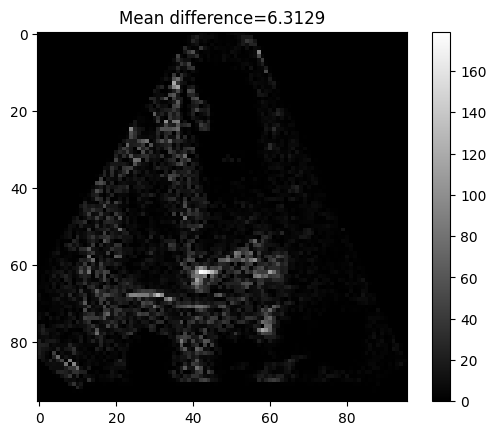

In [ ]:
# Frame squeezing
pre_idx = 3
post_idx = pre_idx + 1
plt.imshow(abs(vid[pre_idx]-vid[post_idx]) * 255, 'gray')
plt.colorbar()
title = np.mean(abs(vid[pre_idx]-vid[post_idx])* 255)
plt.title(f"Mean difference={title:.4f}")

Text(0.5, 1.0, 'Mean difference=6.6468')

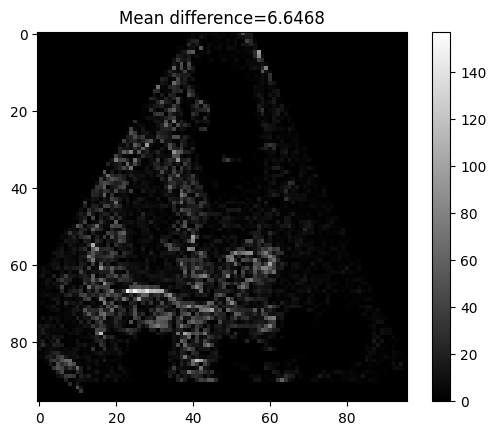

In [121]:
# Distance Base
plt.imshow(abs(vid_new[pre_idx]-vid_new[post_idx]) * 255, 'gray')
plt.colorbar()
title = np.mean(abs(vid_new[pre_idx]-vid_new[post_idx])* 255)
plt.title(f"Mean difference={title:.4f}")

Text(0.5, 1.0, 'Mean difference=3.8993')

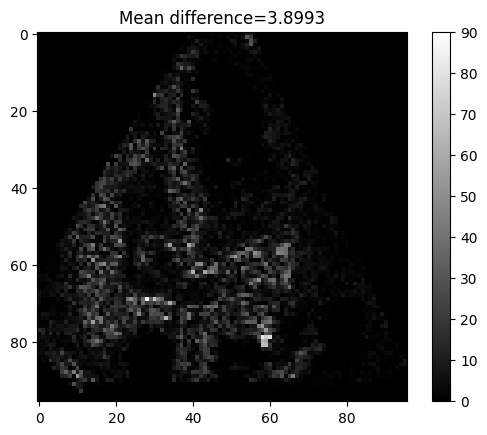

In [122]:
# Lifes
plt.imshow(abs(vid_lifes[pre_idx]-vid_lifes[post_idx]) * 255, 'gray')
plt.colorbar()
title = np.mean(abs(vid_lifes[pre_idx]-vid_lifes[post_idx])* 255)
plt.title(f"Mean difference={title:.4f}")

Text(0.5, 1.0, 'Mean difference=3.0455')

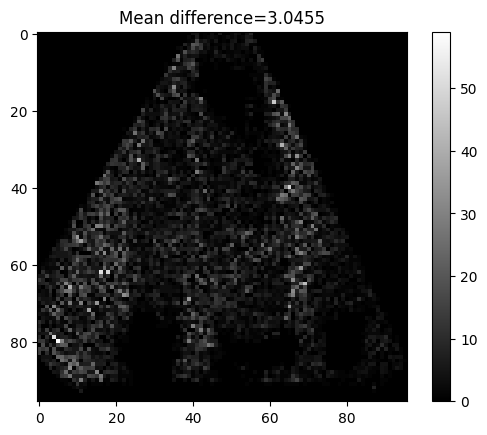

In [123]:
# 10mid
plt.imshow(abs(vid_10mid[pre_idx]-vid_10mid[post_idx]) * 255, 'gray')
plt.colorbar()
title = np.mean(abs(vid_10mid[pre_idx]-vid_10mid[post_idx])* 255)
plt.title(f"Mean difference={title:.4f}")

Text(0.5, 1.0, 'Mean difference=3.6986')

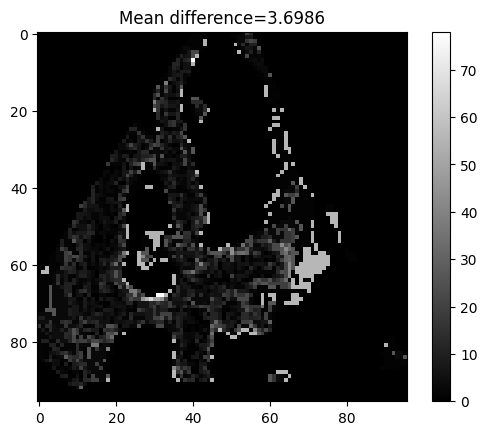

In [124]:
# new_sota
plt.imshow(abs(vid_new_sota[pre_idx]-vid_new_sota[post_idx]) * 255, 'gray')
plt.colorbar()
title = np.mean(abs(vid_new_sota[pre_idx]-vid_new_sota[post_idx])* 255)
plt.title(f"Mean difference={title:.4f}")

Text(0.5, 1.0, 'Mean difference=6.3129')

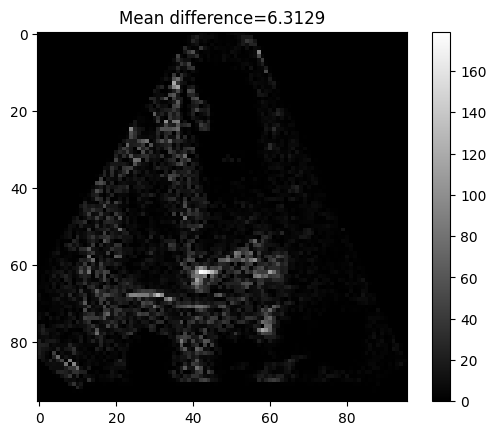

In [125]:
# 16 selective frame
vid_16_selective = np.load('16_selective.npy')
plt.imshow(abs(vid_16_selective[pre_idx]-vid_16_selective[post_idx]) * 255, 'gray')
plt.colorbar()
title = np.mean(abs(vid_16_selective[pre_idx]-vid_16_selective[post_idx])* 255)
plt.title(f"Mean difference={title:.4f}")

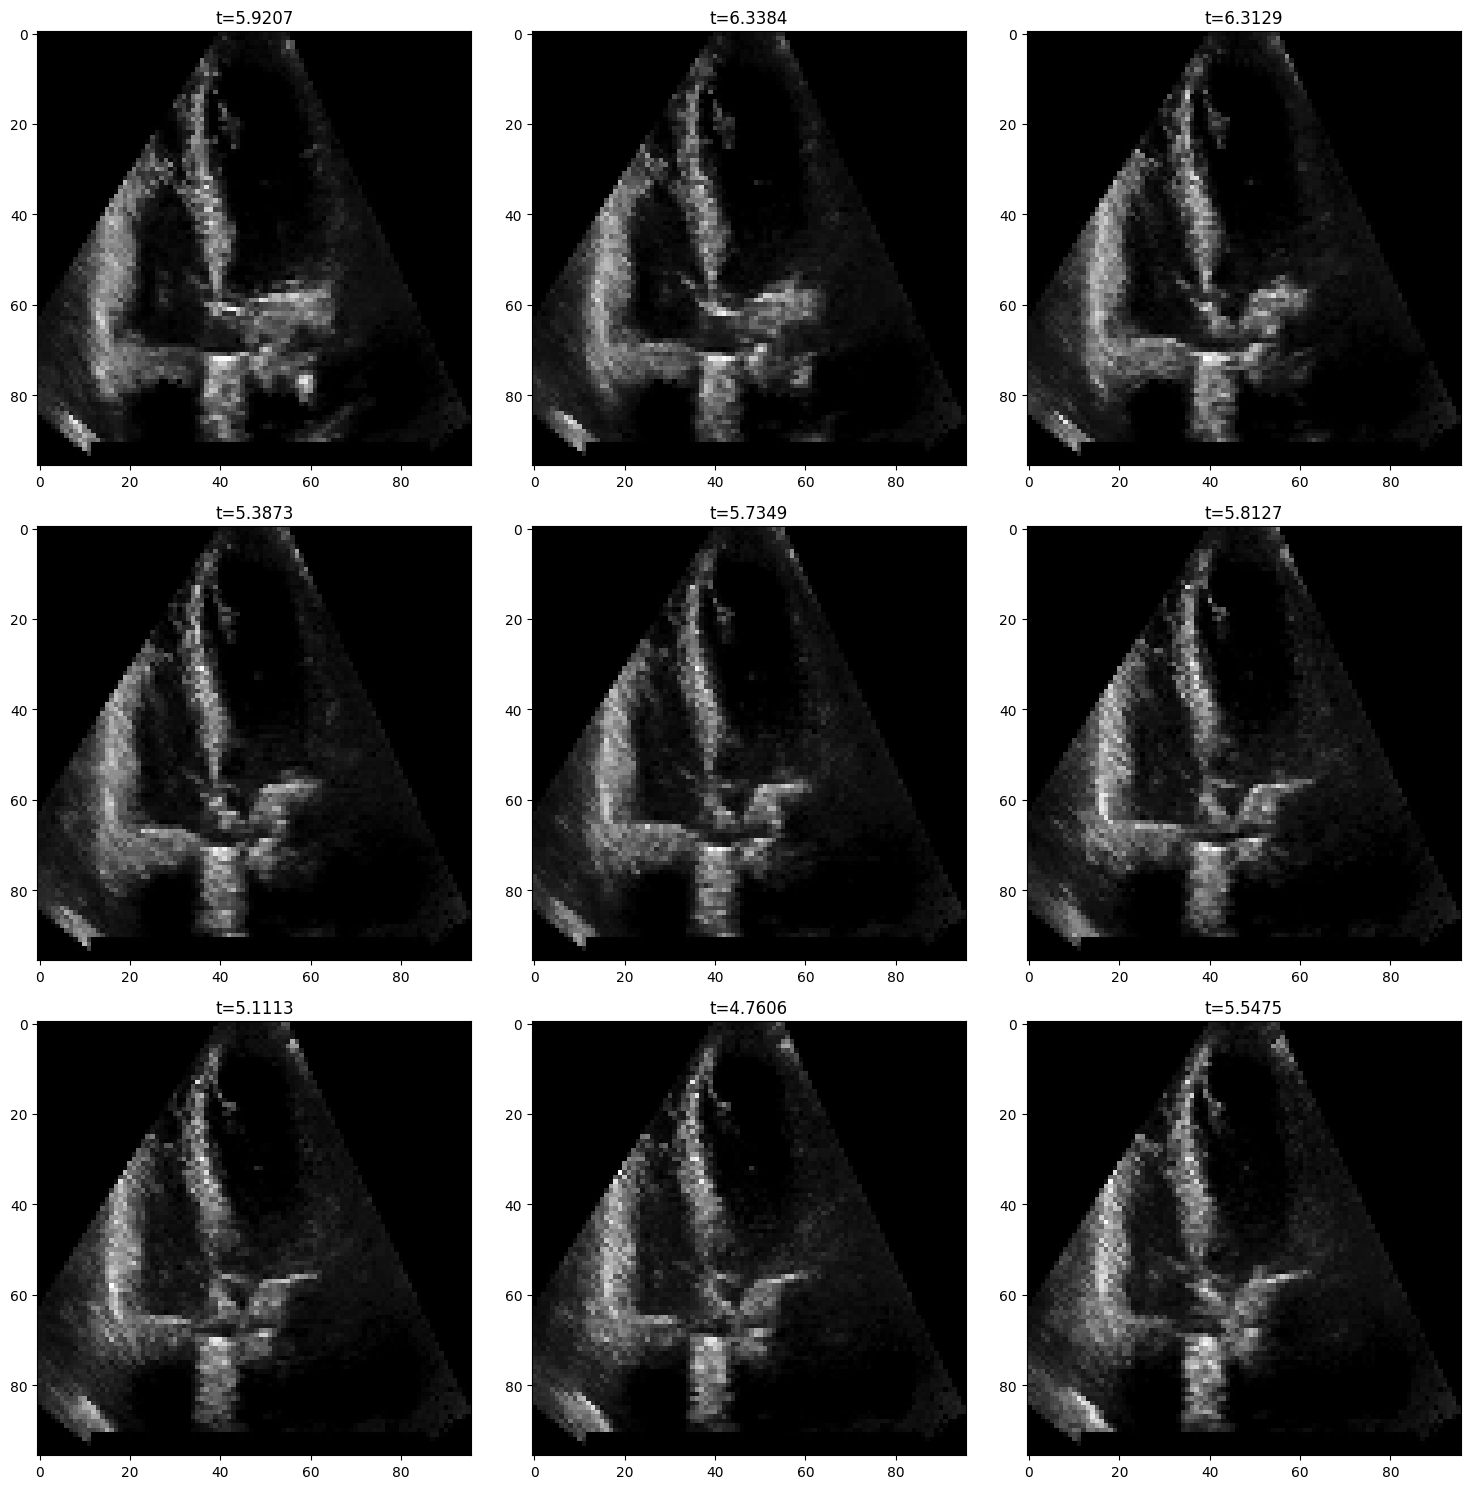

In [126]:
w = 3
h = 3
fig, axs = plt.subplots(w, h, figsize=(15, 15))
idx = 0
for i in range(w):
    for j in range(h):
        # axs[i, j].imshow(vid[idx], cmap='gray')
        axs[i, j].imshow(abs(vid[idx]-vid[idx+1]*255), cmap='gray')
        title = np.mean(abs(vid[idx]-vid[idx+1])*255)
        axs[i, j].set_title(f"t={title:.4f}")
        idx = idx + 1

fig.tight_layout()

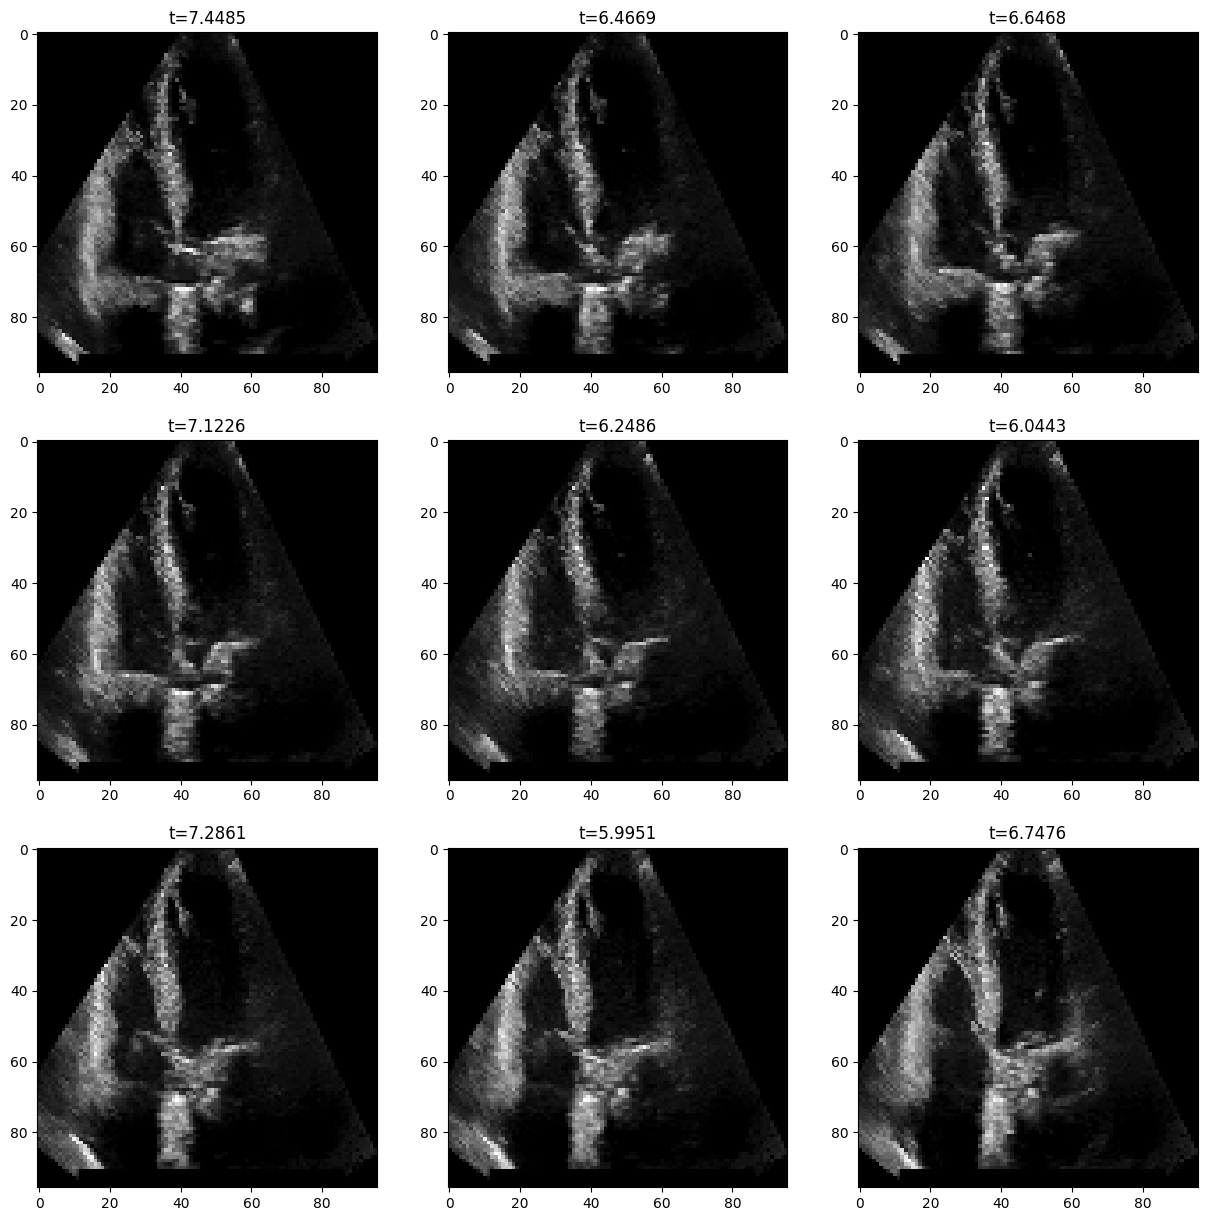

In [127]:
w = 3
h = 3
fig, axs = plt.subplots(w, h, figsize=(15, 15))
idx = 0
for i in range(w):
    for j in range(h):
        # axs[i, j].imshow(vid[idx], cmap='gray')
        axs[i, j].imshow(abs(vid_new[idx]-vid_new[idx+1]*255), cmap='gray')
        title = np.mean(abs(vid_new[idx]-vid_new[idx+1])*255)
        axs[i, j].set_title(f"t={title:.4f}")
        idx = idx + 1